In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

- This datasets is so cute. so I thought why not make a simple regression model for us. 
- For more deeper data understanding

- Data: https://www.kaggle.com/datasets/adarsh2626/indian-all-states-all-district-pollution-dataset/data

In [6]:
path = r"C:\Users\Rudra\Desktop\kaggle\all-india-districts-aqi\all_india_districts_aqi.csv"

In [7]:
df = pd.read_csv(path)
df.head(2)

,State,District,Most AQI Reached,Current AQI,Major Source of Pollution
0,Andhra Pradesh,Anantapur,272,190,Vehicle
1,Andhra Pradesh,Anantapur (Area 1),280,155,Industrial Emissions


In [19]:
df.isnull().sum()

State                        0
District                     0
Most AQI Reached             0
Current AQI                  0
Major Source of Pollution    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5054 entries, 0 to 5053
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   State                      5054 non-null   object
 1   District                   5054 non-null   object
 2   Most AQI Reached           5054 non-null   int64 
 3   Current AQI                5054 non-null   int64 
 4   Major Source of Pollution  5054 non-null   object
dtypes: int64(2), object(3)
memory usage: 197.6+ KB


# EDA

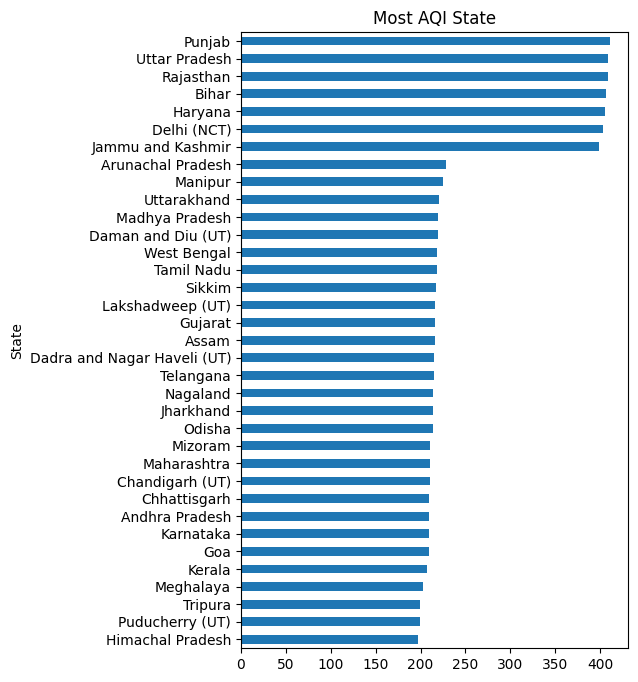

In [18]:
# Most aqi state
plt.figure(figsize=(5, 8))
df.groupby('State')["Most AQI Reached"].mean().sort_values().plot.barh()
plt.title("Most AQI State")
plt.show()

In [20]:
df['Major Source of Pollution'].unique()

array(['Vehicle', 'Industrial Emissions', 'Road Dust', 'Domestic Fuel',
       'Crop Burning', 'Construction Dust', 'Waste Burning'], dtype=object)

In [22]:
df.groupby("Major Source of Pollution")["Most AQI Reached"].mean()

Major Source of Pollution
Construction Dust       294.312732
Crop Burning            275.735799
Domestic Fuel           245.119697
Industrial Emissions    293.470309
Road Dust               242.182594
Vehicle                 297.894668
Waste Burning           249.427892
Name: Most AQI Reached, dtype: float64

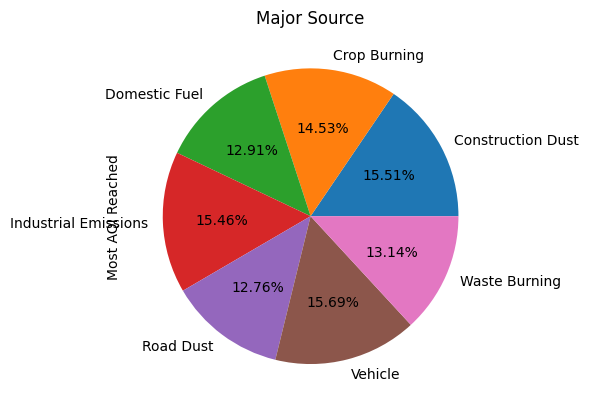

In [24]:
df.groupby("Major Source of Pollution")["Most AQI Reached"].mean().plot.pie(autopct="%2.2f%%" ,title="Major Source")
plt.show()

<Axes: xlabel='Most AQI Reached', ylabel='Current AQI'>

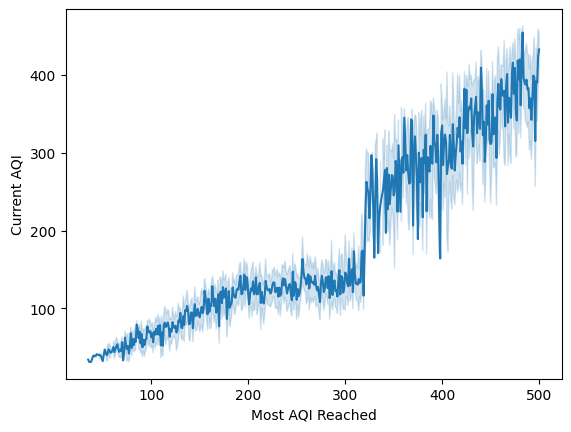

In [28]:
sns.lineplot(
    df,
    x=df["Most AQI Reached"],
    y=df["Current AQI"]
)
plt.title("Most vs Current AQI")
plt.show()

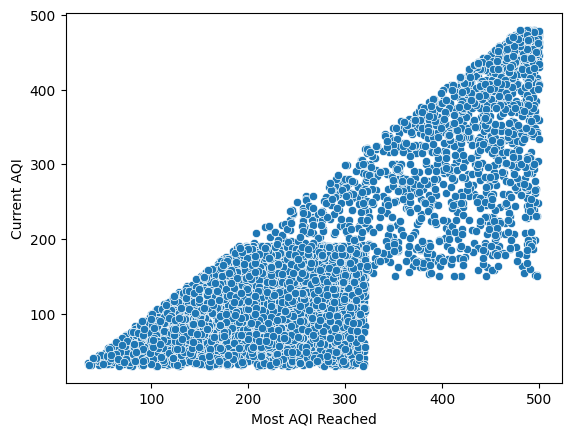

In [29]:
sns.scatterplot(
    df,
    x=df["Most AQI Reached"],
    y=df["Current AQI"]
)
plt.show()

In [31]:
df.describe()

,Most AQI Reached,Current AQI
count,5054.000000,5054.000000
mean,273.862485,173.865453
std,113.511004,116.364175
min,35.000000,30.000000
25%,191.000000,89.000000
50%,259.000000,145.000000
75%,329.000000,212.750000
max,500.000000,480.000000


# Skew Data

- Data is cute
- But inside data we found 
- Features are skewed
- Now how to make model
- Let's see

In [32]:
df[["Most AQI Reached", "Current AQI"]].skew()

Most AQI Reached    0.379539
Current AQI         1.063850
dtype: float64

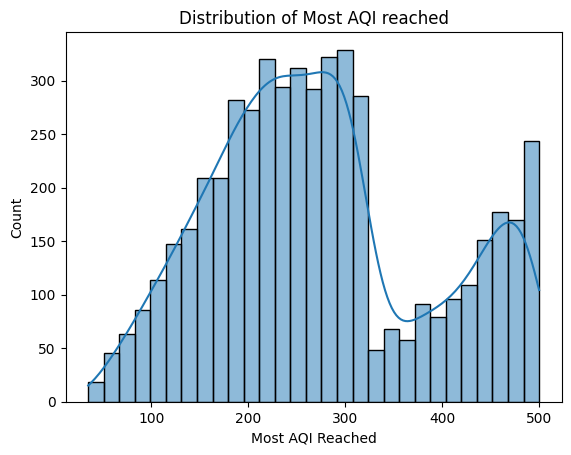

In [37]:
sns.histplot(df["Most AQI Reached"], kde=True)
plt.title("Distribution of Most AQI reached")
plt.show()

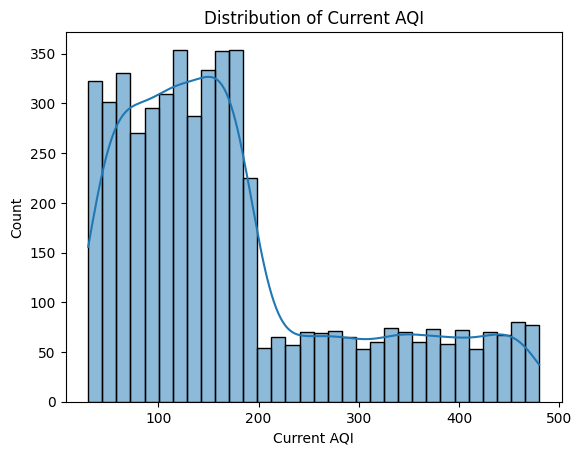

In [36]:
sns.histplot(df["Current AQI"], kde=True)
plt.title("Distribution of Current AQI")
plt.show()

- Our linear regression break 
- For linear regression we assume
- data are normal residuals
- equal variance
- skew data break both

In [40]:
df["Current AQI"].min()

30

If This values is 
- If minimum ≥ 0 → Use log1p
- If minimum > 0 → Use log

In [41]:
df["Current_AQI_log"] = np.log(df["Current AQI"])

In [43]:
df["Current_AQI_log"].skew()

-0.13505577502781604

- Now ok 

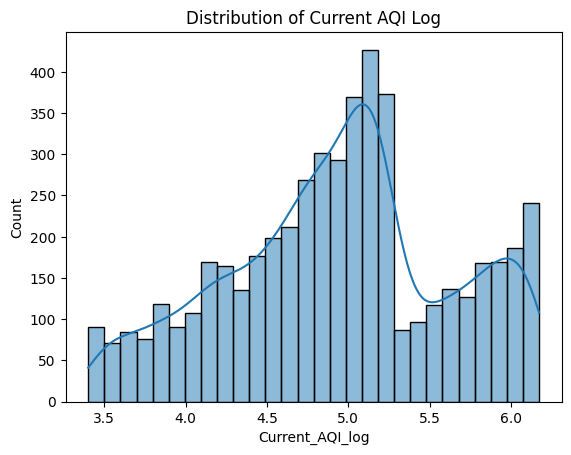

In [42]:
sns.histplot(df["Current_AQI_log"], kde=True)
plt.title("Distribution of Current AQI Log")
plt.show()

# Model

In [25]:
df.columns

Index(['State', 'District', 'Most AQI Reached', 'Current AQI',
       'Major Source of Pollution'],
      dtype='object')

- Which columns for the regressor task
- If you notice we have only two numeric columns

In [44]:
X = df[['Most AQI Reached']]
y = df['Current_AQI_log']

- Current AQI is the target because it is a continuous numeric variable."

- Most AQI Reached is numeric and potentially correlated.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
model = LinearRegression()

In [53]:
model.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred_log = model.predict(X_test)

In [56]:
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

In [57]:
print("R2 Score:", r2_score(y_test_original, y_pred_original))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))
print("MSE:", mean_squared_error(y_test_original, y_pred_original))


R2 Score: 0.691176725454095
MAE: 49.97227079580732
MSE: 3890.842132357514


In [58]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.00460491]
Intercept: 3.674730944964139


In [64]:
# if we try random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_rf))


R2: 0.5547108667455181


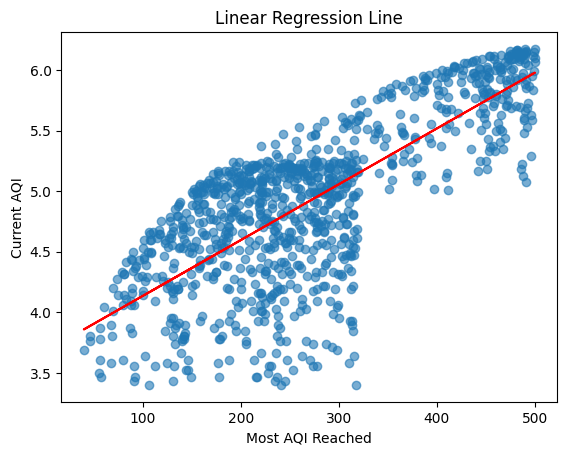

In [66]:
# Scatter plot
plt.scatter(X_test, y_test, alpha=0.6)

# Regression line
plt.plot(X_test, y_pred_log, color='red')

plt.xlabel("Most AQI Reached")
plt.ylabel("Current AQI")
plt.title("Linear Regression Line")
plt.show()


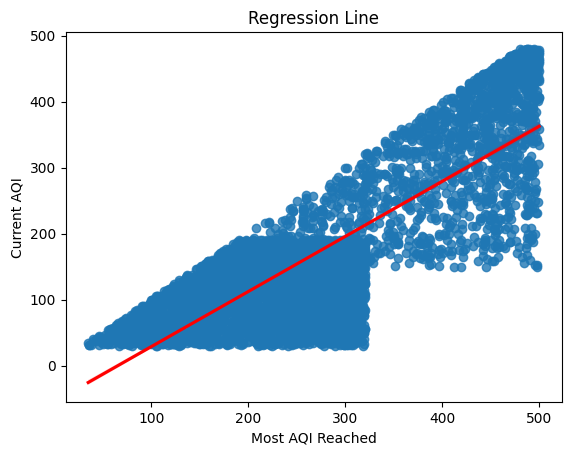

In [63]:
sns.regplot(
    x="Most AQI Reached",
    y="Current AQI",
    data=df,
    line_kws={"color": "red"}
)

plt.title("Regression Line")
plt.show()
